# Chapter 1 ASIC Hard-Case Review

This notebook is a thin review layer over the saved ASIC Chapter 1 hard-case artifacts. It does **not** rerun hard-case classification logic. The goal is quick first-pass QC on subgroup size, horizon variation, site concentration, threshold context, and cross-model agreement.
        

## 1. Load And Sanity Check Data
        

In [1]:
from __future__ import annotations

import os
import sys
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd

if "MPLCONFIGDIR" not in os.environ:
    mplconfigdir = Path("/tmp") / "chapter1_mortality_decomposition_matplotlib"
    mplconfigdir.mkdir(parents=True, exist_ok=True)
    os.environ["MPLCONFIGDIR"] = str(mplconfigdir)

try:
    from IPython import get_ipython
    from IPython.display import Image, Markdown, display
    ipython_shell = get_ipython()
    if ipython_shell is None:
        raise RuntimeError("Plain Python execution: use fallback display helpers.")
    try:
        ipython_shell.run_line_magic("matplotlib", "inline")
    except Exception:
        pass
except Exception:
    ipython_shell = None

    class Markdown(str):
        pass

    def display(obj: object) -> None:
        print(obj)

import matplotlib
if ipython_shell is None:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt


def finalize_figure(fig=None) -> None:
    fig = fig or plt.gcf()
    backend = matplotlib.get_backend().lower()
    if "agg" in backend:
        if ipython_shell is not None:
            buffer = BytesIO()
            fig.savefig(buffer, format="png", bbox_inches="tight")
            buffer.seek(0)
            display(Image(data=buffer.getvalue()))
            buffer.close()
        plt.close(fig)
        return
    plt.show()


def looks_like_repo_root(path: Path) -> bool:
    return (path / "pyproject.toml").exists() and (path / "src" / "chapter1_mortality_decomposition").exists()


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if looks_like_repo_root(candidate):
            return candidate
    raise RuntimeError("Could not locate the repository root from the current working directory.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from chapter1_mortality_decomposition.hard_case_definition import DEFAULT_HARD_CASE_OUTPUT_DIR

try:
    from chapter1_mortality_decomposition.hard_case_agreement import DEFAULT_AGREEMENT_OUTPUT_DIR
except Exception:
    DEFAULT_AGREEMENT_OUTPUT_DIR = None

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

PRIMARY_HORIZON = 24
SECONDARY_HORIZON = 48

LOGISTIC_HARD_CASE_ROOT = REPO_ROOT / DEFAULT_HARD_CASE_OUTPUT_DIR
LOGISTIC_STAY_LEVEL_PATH = LOGISTIC_HARD_CASE_ROOT / "stay_level_hard_case_flags.csv"
LOGISTIC_SUMMARY_PATH = LOGISTIC_HARD_CASE_ROOT / "horizon_hard_case_summary.csv"

AGREEMENT_ROOT = REPO_ROOT / DEFAULT_AGREEMENT_OUTPUT_DIR if DEFAULT_AGREEMENT_OUTPUT_DIR is not None else None
AGREEMENT_STAY_LEVEL_PATH = (
    AGREEMENT_ROOT / "fatal_stay_level_hard_case_agreement.csv"
    if AGREEMENT_ROOT is not None
    else None
)
AGREEMENT_SUMMARY_PATH = (
    AGREEMENT_ROOT / "horizon_hard_case_agreement_summary.csv"
    if AGREEMENT_ROOT is not None
    else None
)


def relative_path(path: Path | None) -> str:
    if path is None:
        return "<not configured>"
    try:
        return str(path.resolve().relative_to(REPO_ROOT))
    except Exception:
        return str(path)


def read_csv_required(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Required hard-case artifact is missing: {path}")
    return pd.read_csv(path)


def read_csv_optional(path: Path | None) -> pd.DataFrame:
    if path is None or not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)


logistic_stay = read_csv_required(LOGISTIC_STAY_LEVEL_PATH)
logistic_summary = read_csv_required(LOGISTIC_SUMMARY_PATH)
agreement_stay = read_csv_optional(AGREEMENT_STAY_LEVEL_PATH)
agreement_summary = read_csv_optional(AGREEMENT_SUMMARY_PATH)
agreement_available = not agreement_stay.empty and not agreement_summary.empty


def extract_model_labels(frame: pd.DataFrame) -> str:
    labels: list[str] = []
    for column in frame.columns:
        if column == "model_name":
            labels.extend(frame[column].dropna().astype("string").unique().tolist())
        elif column.endswith("_model_name"):
            labels.extend(frame[column].dropna().astype("string").unique().tolist())
    ordered: list[str] = []
    seen: set[str] = set()
    for label in labels:
        if label not in seen:
            ordered.append(label)
            seen.add(label)
    return ", ".join(ordered) if ordered else "n/a"


artifact_paths = pd.DataFrame(
    [
        {
            "artifact_name": "logistic stay-level hard cases",
            "path": relative_path(LOGISTIC_STAY_LEVEL_PATH),
            "required": True,
            "exists": LOGISTIC_STAY_LEVEL_PATH.exists(),
        },
        {
            "artifact_name": "logistic horizon summary",
            "path": relative_path(LOGISTIC_SUMMARY_PATH),
            "required": True,
            "exists": LOGISTIC_SUMMARY_PATH.exists(),
        },
        {
            "artifact_name": "agreement stay-level artifact",
            "path": relative_path(AGREEMENT_STAY_LEVEL_PATH),
            "required": False,
            "exists": bool(AGREEMENT_STAY_LEVEL_PATH is not None and AGREEMENT_STAY_LEVEL_PATH.exists()),
        },
        {
            "artifact_name": "agreement horizon summary",
            "path": relative_path(AGREEMENT_SUMMARY_PATH),
            "required": False,
            "exists": bool(AGREEMENT_SUMMARY_PATH is not None and AGREEMENT_SUMMARY_PATH.exists()),
        },
    ]
)

def describe_frame(name: str, frame: pd.DataFrame) -> dict[str, object]:
    return {
        "artifact_name": name,
        "row_count": int(frame.shape[0]),
        "available_horizons": ", ".join(str(h) for h in sorted(pd.to_numeric(frame["horizon_h"], errors="coerce").dropna().astype(int).unique().tolist())) if "horizon_h" in frame.columns else "n/a",
        "hospital_count": int(frame["hospital_id"].nunique(dropna=True)) if "hospital_id" in frame.columns else pd.NA,
        "available_models": extract_model_labels(frame),
    }


artifact_overview = pd.DataFrame(
    [
        describe_frame("logistic stay-level hard cases", logistic_stay),
        describe_frame("logistic horizon summary", logistic_summary),
        describe_frame("agreement stay-level artifact", agreement_stay) if agreement_available else describe_frame("agreement stay-level artifact", pd.DataFrame()),
        describe_frame("agreement horizon summary", agreement_summary) if agreement_available else describe_frame("agreement horizon summary", pd.DataFrame()),
    ]
)

primary_sanity = pd.DataFrame(
    [
        {"metric": "repo_root", "value": str(REPO_ROOT)},
        {"metric": "logistic stay-level rows", "value": int(logistic_stay.shape[0])},
        {"metric": "available horizons", "value": ", ".join(str(h) for h in sorted(logistic_stay["horizon_h"].dropna().astype(int).unique().tolist()))},
        {"metric": "available hospitals", "value": ", ".join(sorted(logistic_stay["hospital_id"].dropna().astype("string").unique().tolist()))},
        {"metric": "fatal last-point rows", "value": int(logistic_stay["label_value"].eq(1).sum())},
        {"metric": "hard-case rows", "value": int(logistic_stay["hard_case_flag"].astype(bool).sum())},
        {"metric": "agreement artifacts available", "value": bool(agreement_available)},
    ]
)

primary_qc_columns = [
    "stay_id_global",
    "hospital_id",
    "horizon_h",
    "label_value",
    "instance_id",
    "block_index",
    "prediction_time_h",
    "predicted_probability",
    "nonfatal_q75_threshold",
    "hard_case_flag",
]

display(Markdown("### Artifact Paths"))
display(artifact_paths)

display(Markdown("### Artifact Overview"))
display(artifact_overview)

display(Markdown("### Primary Hard-Case Sanity Summary"))
display(primary_sanity)

display(Markdown("### Primary Stay-Level QC Preview"))
display(logistic_stay[primary_qc_columns].head(12))

display(Markdown("### Primary Horizon Summary"))
display(logistic_summary)

if agreement_available:
    agreement_qc_columns = [
        "stay_id_global",
        "hospital_id",
        "horizon_h",
        "logistic_predicted_probability",
        "logistic_hard_case_flag",
        "xgb_recal_predicted_probability",
        "xgb_recal_hard_case_flag",
        "hard_case_agreement_flag",
        "hard_case_logistic_only_flag",
        "hard_case_xgb_only_flag",
    ]
    display(Markdown("### Agreement Artifact QC Preview"))
    display(agreement_stay[agreement_qc_columns].head(12))
else:
    display(Markdown("_Agreement artifacts are not available at the configured default path, so the cross-model section below will be skipped._"))
        

### Artifact Paths

,artifact_name,path,required,exists
0,logistic stay-level hard cases,artifacts/chapter1/evaluation/asic/hard_cases/...,True,True
1,logistic horizon summary,artifacts/chapter1/evaluation/asic/hard_cases/...,True,True
2,agreement stay-level artifact,artifacts/chapter1/evaluation/asic/hard_cases/...,False,True
3,agreement horizon summary,artifacts/chapter1/evaluation/asic/hard_cases/...,False,True


### Artifact Overview

,artifact_name,row_count,available_horizons,hospital_count,available_models
0,logistic stay-level hard cases,171,"8, 16, 24, 48, 72",4,logistic_regression
1,logistic horizon summary,5,"8, 16, 24, 48, 72",<NA>,logistic_regression
2,agreement stay-level artifact,50,"8, 16, 24, 48, 72",4,"logistic_regression, xgboost_platt"
3,agreement horizon summary,5,"8, 16, 24, 48, 72",<NA>,"logistic_regression, xgboost_platt"


### Primary Hard-Case Sanity Summary

...

,stay_id_global,hospital_id,horizon_h,label_value,instance_id,block_index,prediction_time_h,predicted_probability,nonfatal_q75_threshold,hard_case_flag
0,asic_UK02_9990,asic_UK02,8,0,asic_UK02_9990__b36__h8,36,296,1.741766e-02,0.008151,False
1,asic_UK02_9991,asic_UK02,8,0,asic_UK02_9991__b60__h8,60,488,5.549880e-08,0.008151,False
2,asic_UK02_9992,asic_UK02,8,1,asic_UK02_9992__b3__h8,3,32,3.188874e-01,0.008151,False
3,asic_UK02_9993,asic_UK02,8,0,asic_UK02_9993__b12__h8,12,104,9.770608e-05,0.008151,False
4,asic_UK02_9994,asic_UK02,8,1,asic_UK02_9994__b105__h8,105,848,3.544102e-01,0.008151,False
5,asic_UK02_9995,asic_UK02,8,0,asic_UK02_9995__b47__h8,47,384,4.991000e-03,0.008151,False
6,asic_UK02_9996,asic_UK02,8,0,asic_UK02_9996__b6__h8,6,56,2.706164e-04,0.008151,False
7,asic_UK02_9997,asic_UK02,8,1,asic_UK02_9997__b34__h8,34,280,3.095516e-01,0.008151,False
8,asic_UK02_9998,asic_UK02,8,1,asic_UK02_9998__b34__h8,34,280,5.966758e-03,0.008151,True
9,asic_UK02_9999,asic_UK02,8,0,asic_UK02_9999__b21__h8,21,176,1.172383e-03,0.008151,False


### Primary Horizon Summary

,horizon_h,model_name,n_prediction_rows_loaded,n_rows_collapsed_before_last_point,n_selected_last_points,n_nonfatal_last_points,n_fatal_last_points,nonfatal_q75_threshold,n_hard_cases,pct_fatal_hard_cases,subgroup_size_warning,warning_reason
0,8,logistic_regression,1256,1221,35,25,10,0.008151,4,0.4,True,n_hard_cases_lt_20
1,16,logistic_regression,1244,1209,35,25,10,0.027625,4,0.4,True,n_hard_cases_lt_20
2,24,logistic_regression,1232,1197,35,25,10,0.040880,4,0.4,True,n_hard_cases_lt_20
3,48,logistic_regression,1194,1160,34,24,10,0.110249,5,0.5,True,n_hard_cases_lt_20
4,72,logistic_regression,1154,1122,32,22,10,0.163779,6,0.6,True,n_hard_cases_lt_20


### Agreement Artifact QC Preview

,stay_id_global,hospital_id,horizon_h,logistic_predicted_probability,logistic_hard_case_flag,xgb_recal_predicted_probability,xgb_recal_hard_case_flag,hard_case_agreement_flag,hard_case_logistic_only_flag,hard_case_xgb_only_flag
0,asic_UK02_9992,asic_UK02,8,0.318887,False,0.032404,False,False,False,False
1,asic_UK02_9994,asic_UK02,8,0.354410,False,0.032739,False,False,False,False
2,asic_UK02_9997,asic_UK02,8,0.309552,False,0.031410,False,False,False,False
3,asic_UK02_9998,asic_UK02,8,0.005967,True,0.010455,False,False,True,False
4,asic_UK04_9991,asic_UK04,8,0.086613,False,0.031189,False,False,False,False
5,asic_UK04_9992,asic_UK04,8,0.053639,False,0.028622,False,False,False,False
6,asic_UK07_9990,asic_UK07,8,0.004743,True,0.031914,False,False,True,False
7,asic_UK07_9994,asic_UK07,8,0.003830,True,0.030378,False,False,True,False
8,asic_UK07_9998,asic_UK07,8,0.000291,True,0.006787,True,True,False,False
9,asic_UK08_9995,asic_UK08,8,0.022438,False,0.027753,False,False,False,False


In [2]:
def plot_annotated_heatmap(
    table: pd.DataFrame,
    *,
    ax: plt.Axes,
    title: str,
    cmap: str = "Blues",
    value_format: str = "{:.0f}",
    colorbar_label: str | None = None,
    vmin: float | None = None,
    vmax: float | None = None,
) -> None:
    if table.empty:
        ax.axis("off")
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=11)
        ax.set_title(title)
        return

    values = table.to_numpy(dtype=float)
    if np.isfinite(values).any():
        if vmin is None:
            vmin = float(np.nanmin(values))
        if vmax is None:
            vmax = float(np.nanmax(values))
    image = ax.imshow(values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(table.shape[1]))
    ax.set_xticklabels([str(column) for column in table.columns])
    ax.set_yticks(range(table.shape[0]))
    ax.set_yticklabels([str(index) for index in table.index])
    ax.set_xlabel("Horizon (h)")
    ax.set_ylabel("Hospital")
    ax.set_title(title)

    for row_idx in range(table.shape[0]):
        for col_idx in range(table.shape[1]):
            value = values[row_idx, col_idx]
            if np.isnan(value):
                label = ""
            else:
                label = value_format.format(value)
            ax.text(col_idx, row_idx, label, ha="center", va="center", color="black", fontsize=9)

    colorbar = plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    if colorbar_label is not None:
        colorbar.set_label(colorbar_label)


def plot_last_point_risk_distribution(
    stay_level: pd.DataFrame,
    *,
    horizon_h: int,
    ax: plt.Axes,
) -> None:
    subset = stay_level[stay_level["horizon_h"].astype(int).eq(int(horizon_h))].copy()
    if subset.empty:
        ax.axis("off")
        ax.text(0.5, 0.5, f"No rows for {horizon_h}h", ha="center", va="center")
        ax.set_title(f"{horizon_h}h")
        return

    threshold = float(subset["nonfatal_q75_threshold"].dropna().iloc[0])
    nonfatal = subset.loc[subset["label_value"].eq(0), "predicted_probability"].astype(float)
    fatal_nonhard = subset.loc[
        subset["label_value"].eq(1) & ~subset["hard_case_flag"].astype(bool),
        "predicted_probability",
    ].astype(float)
    fatal_hard = subset.loc[subset["hard_case_flag"].astype(bool), "predicted_probability"].astype(float)

    combined = pd.concat([nonfatal, fatal_nonhard, fatal_hard], ignore_index=True)
    positive = combined[np.isfinite(combined) & combined.gt(0)]
    if positive.empty:
        lower = 1e-6
        upper = 1.0
    else:
        lower = max(float(positive.min()), 1e-6)
        upper = max(float(positive.max()) * 1.15, threshold * 1.15, lower * 10)
    bins = np.geomspace(lower, upper, 28)

    def clipped(series: pd.Series) -> np.ndarray:
        values = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        return np.clip(values, lower, None)

    ax.hist(clipped(nonfatal), bins=bins, alpha=0.65, color="#4c78a8", label=f"Nonfatal (n={len(nonfatal)})")
    ax.hist(clipped(fatal_nonhard), bins=bins, alpha=0.60, color="#f58518", label=f"Fatal non-hard (n={len(fatal_nonhard)})")
    if len(fatal_hard) > 0:
        ax.hist(clipped(fatal_hard), bins=bins, alpha=0.85, color="#e45756", label=f"Fatal hard case (n={len(fatal_hard)})")
    ax.axvline(max(threshold, lower), color="black", linestyle="--", linewidth=1.6, label=f"Nonfatal q75 = {threshold:.4f}")
    ax.set_xscale("log")
    ax.set_xlabel("Last-point predicted probability (log scale)")
    ax.set_ylabel("Stay count")
    ax.set_title(f"{int(horizon_h)}h last-point risk distribution")
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.legend(fontsize=9)


def agreement_category(frame: pd.DataFrame) -> pd.Series:
    category = pd.Series("neither", index=frame.index, dtype="string")
    category = category.mask(frame["hard_case_agreement_flag"].astype(bool), "both")
    category = category.mask(frame["hard_case_logistic_only_flag"].astype(bool), "logistic_only")
    category = category.mask(frame["hard_case_xgb_only_flag"].astype(bool), "xgb_only")
    return category
        

## 2. Hard-Case Subgroup Size And Rates
        

### Compact Summary Table

,horizon_h,nonfatal_q75_threshold,n_fatal_last_points,n_hard_cases,pct_fatal_hard_cases,subgroup_size_warning,warning_reason
0,8,0.008151,10,4,0.4,True,n_hard_cases_lt_20
1,16,0.027625,10,4,0.4,True,n_hard_cases_lt_20
2,24,0.040880,10,4,0.4,True,n_hard_cases_lt_20
3,48,0.110249,10,5,0.5,True,n_hard_cases_lt_20
4,72,0.163779,10,6,0.6,True,n_hard_cases_lt_20


### Threshold Table

,horizon_h,nonfatal_q75_threshold
0,8,0.008151
1,16,0.027625
2,24,0.040880
3,48,0.110249
4,72,0.163779


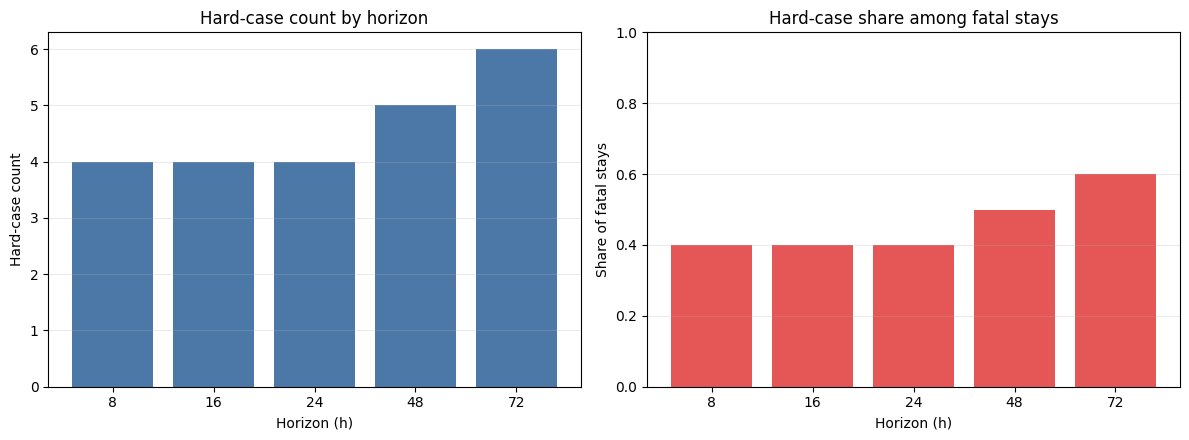

In [3]:
hard_case_overview = logistic_summary[
    [
        "horizon_h",
        "nonfatal_q75_threshold",
        "n_fatal_last_points",
        "n_hard_cases",
        "pct_fatal_hard_cases",
        "subgroup_size_warning",
        "warning_reason",
    ]
].sort_values("horizon_h").reset_index(drop=True)

display(Markdown("### Compact Summary Table"))
display(hard_case_overview)

display(Markdown("### Threshold Table"))
display(logistic_summary[["horizon_h", "nonfatal_q75_threshold"]].sort_values("horizon_h").reset_index(drop=True))

plot_frame = logistic_summary.sort_values("horizon_h").reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
axes[0].bar(plot_frame["horizon_h"].astype(str), plot_frame["n_hard_cases"], color="#4c78a8")
axes[0].set_title("Hard-case count by horizon")
axes[0].set_xlabel("Horizon (h)")
axes[0].set_ylabel("Hard-case count")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(plot_frame["horizon_h"].astype(str), plot_frame["pct_fatal_hard_cases"], color="#e45756")
axes[1].set_title("Hard-case share among fatal stays")
axes[1].set_xlabel("Horizon (h)")
axes[1].set_ylabel("Share of fatal stays")
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
finalize_figure(fig)
        

## 3. Threshold Context / Risk-Distribution Visualization

These plots use the saved stay-level last-point artifact only. They show the nonfatal distribution, the fatal non-hard distribution, the hard-case fatal distribution, and the horizon-specific nonfatal `q75` threshold.
        

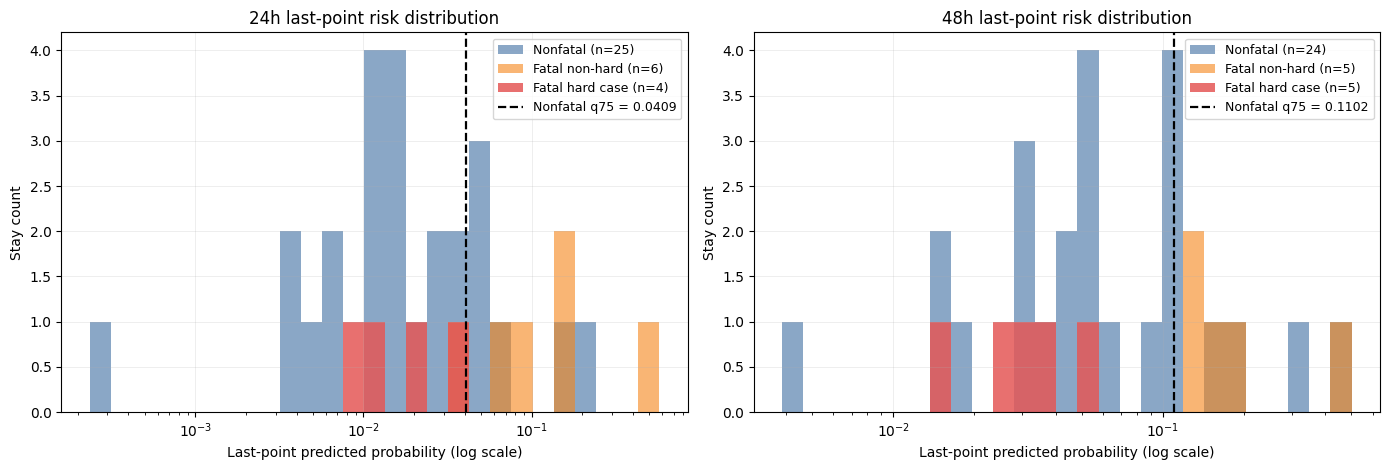

### Distribution Context Table

,horizon_h,group,n,min,median,p75,max
0,24,nonfatal,25,0.000235,0.016674,0.040880,0.204325
1,24,fatal,10,0.008142,0.056317,0.135164,0.498050
2,24,fatal_hard,4,0.008142,0.016979,0.025001,0.033520
3,48,nonfatal,24,0.003874,0.051994,0.110249,0.435426
4,48,fatal,10,0.013824,0.088768,0.149375,0.422187
5,48,fatal_hard,5,0.013824,0.032616,0.035457,0.048449


In [4]:
selected_horizons = [h for h in [PRIMARY_HORIZON, SECONDARY_HORIZON] if h in logistic_stay["horizon_h"].astype(int).unique().tolist()]
fig, axes = plt.subplots(1, len(selected_horizons), figsize=(7 * len(selected_horizons), 4.8))
if len(selected_horizons) == 1:
    axes = [axes]
for ax, horizon_h in zip(axes, selected_horizons):
    plot_last_point_risk_distribution(logistic_stay, horizon_h=horizon_h, ax=ax)
plt.tight_layout()
finalize_figure(fig)

risk_quantiles = []
for horizon_h in selected_horizons:
    subset = logistic_stay[logistic_stay["horizon_h"].astype(int).eq(int(horizon_h))].copy()
    for label, frame in [
        ("nonfatal", subset[subset["label_value"].eq(0)]),
        ("fatal", subset[subset["label_value"].eq(1)]),
        ("fatal_hard", subset[subset["hard_case_flag"].astype(bool)]),
    ]:
        if frame.empty:
            continue
        risk_quantiles.append(
            {
                "horizon_h": int(horizon_h),
                "group": label,
                "n": int(frame.shape[0]),
                "min": float(frame["predicted_probability"].min()),
                "median": float(frame["predicted_probability"].median()),
                "p75": float(frame["predicted_probability"].quantile(0.75)),
                "max": float(frame["predicted_probability"].max()),
            }
        )

display(Markdown("### Distribution Context Table"))
display(pd.DataFrame(risk_quantiles))
        

## 4. Hospital / Site Breakdown
        

### Hospital-Horizon Table

,hospital_id,horizon_h,fatal_stays,hard_cases,hard_case_rate_among_fatal
0,asic_UK02,8,4,1,0.25
1,asic_UK02,16,4,1,0.25
2,asic_UK02,24,4,0,0.00
3,asic_UK02,48,4,1,0.25
4,asic_UK02,72,4,1,0.25
5,asic_UK04,8,2,0,0.00
6,asic_UK04,16,2,0,0.00
7,asic_UK04,24,2,1,0.50
8,asic_UK04,48,2,0,0.00
9,asic_UK04,72,2,1,0.50


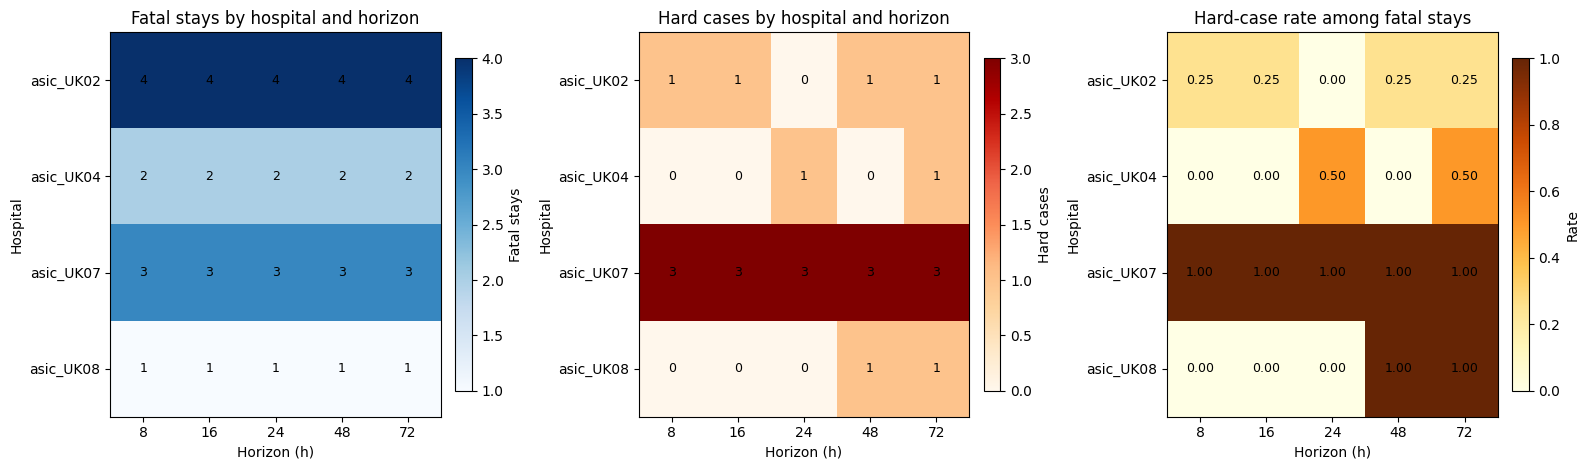

In [5]:
hospital_horizon = (
    logistic_stay.groupby(["hospital_id", "horizon_h"], dropna=False)
    .agg(
        fatal_stays=("label_value", lambda series: int(pd.Series(series).eq(1).sum())),
        hard_cases=("hard_case_flag", lambda series: int(pd.Series(series).astype(bool).sum())),
    )
    .reset_index()
    .sort_values(["hospital_id", "horizon_h"])
    .reset_index(drop=True)
)
hospital_horizon["hard_case_rate_among_fatal"] = hospital_horizon.apply(
    lambda row: float(row["hard_cases"] / row["fatal_stays"]) if row["fatal_stays"] else np.nan,
    axis=1,
)

display(Markdown("### Hospital-Horizon Table"))
display(hospital_horizon)

fatal_table = hospital_horizon.pivot(index="hospital_id", columns="horizon_h", values="fatal_stays").sort_index(axis=1)
hard_table = hospital_horizon.pivot(index="hospital_id", columns="horizon_h", values="hard_cases").sort_index(axis=1)
rate_table = hospital_horizon.pivot(index="hospital_id", columns="horizon_h", values="hard_case_rate_among_fatal").sort_index(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
plot_annotated_heatmap(fatal_table, ax=axes[0], title="Fatal stays by hospital and horizon", cmap="Blues", value_format="{:.0f}", colorbar_label="Fatal stays")
plot_annotated_heatmap(hard_table, ax=axes[1], title="Hard cases by hospital and horizon", cmap="OrRd", value_format="{:.0f}", colorbar_label="Hard cases")
plot_annotated_heatmap(rate_table, ax=axes[2], title="Hard-case rate among fatal stays", cmap="YlOrBr", value_format="{:.2f}", colorbar_label="Rate", vmin=0.0, vmax=1.0)
plt.tight_layout()
finalize_figure(fig)
        

## 5. Example Stay-Level View Of Selected Hard Cases
        

In [6]:
example_columns = [
    "stay_id_global",
    "hospital_id",
    "horizon_h",
    "instance_id",
    "block_index",
    "prediction_time_h",
    "predicted_probability",
    "nonfatal_q75_threshold",
    "hard_case_flag",
]

lowest_hard_cases = (
    logistic_stay[logistic_stay["hard_case_flag"].astype(bool)]
    .sort_values(["predicted_probability", "horizon_h", "hospital_id", "stay_id_global"])
    .loc[:, example_columns]
    .head(10)
    .reset_index(drop=True)
)

near_threshold_nonhard_fatal = (
    logistic_stay[
        logistic_stay["label_value"].eq(1) & ~logistic_stay["hard_case_flag"].astype(bool)
    ]
    .assign(distance_to_threshold=lambda frame: (frame["predicted_probability"] - frame["nonfatal_q75_threshold"]).abs())
    .sort_values(["distance_to_threshold", "horizon_h", "hospital_id", "stay_id_global"])
    .loc[:, [*example_columns, "distance_to_threshold"]]
    .head(10)
    .reset_index(drop=True)
)

display(Markdown("### 10 hard cases with the lowest predicted probability"))
display(lowest_hard_cases)

display(Markdown("### 10 non-hard fatal stays closest to the horizon-specific threshold"))
display(near_threshold_nonhard_fatal)
        

### 10 hard cases with the lowest predicted probability

,stay_id_global,hospital_id,horizon_h,instance_id,block_index,prediction_time_h,predicted_probability,nonfatal_q75_threshold,hard_case_flag
0,asic_UK07_9998,asic_UK07,8,asic_UK07_9998__b26__h8,26,216,0.000291,0.008151,True
1,asic_UK07_9998,asic_UK07,16,asic_UK07_9998__b26__h16,26,216,0.003309,0.027625,True
2,asic_UK07_9994,asic_UK07,8,asic_UK07_9994__b115__h8,115,928,0.003830,0.008151,True
3,asic_UK07_9990,asic_UK07,8,asic_UK07_9990__b13__h8,13,112,0.004743,0.008151,True
4,asic_UK07_9990,asic_UK07,16,asic_UK07_9990__b13__h16,13,112,0.005449,0.027625,True
5,asic_UK02_9998,asic_UK02,8,asic_UK02_9998__b34__h8,34,280,0.005967,0.008151,True
6,asic_UK07_9994,asic_UK07,24,asic_UK07_9994__b115__h24,115,928,0.008142,0.040880,True
7,asic_UK07_9994,asic_UK07,16,asic_UK07_9994__b115__h16,115,928,0.008241,0.027625,True
8,asic_UK02_9998,asic_UK02,16,asic_UK02_9998__b34__h16,34,280,0.008705,0.027625,True
9,asic_UK08_9995,asic_UK08,72,asic_UK08_9995__b5__h72,5,48,0.011618,0.163779,True


### 10 non-hard fatal stays closest to the horizon-specific threshold

,stay_id_global,hospital_id,horizon_h,instance_id,block_index,prediction_time_h,predicted_probability,nonfatal_q75_threshold,hard_case_flag,distance_to_threshold
0,asic_UK08_9995,asic_UK08,24,asic_UK08_9995__b5__h24,5,48,0.041318,0.040880,False,0.000438
1,asic_UK04_9992,asic_UK04,16,asic_UK04_9992__b11__h16,11,96,0.038006,0.027625,False,0.010380
2,asic_UK08_9995,asic_UK08,8,asic_UK08_9995__b5__h8,5,48,0.022438,0.008151,False,0.014286
3,asic_UK04_9991,asic_UK04,48,asic_UK04_9991__b54__h48,54,440,0.129087,0.110249,False,0.018838
4,asic_UK04_9992,asic_UK04,48,asic_UK04_9992__b11__h48,11,96,0.130794,0.110249,False,0.020545
5,asic_UK02_9998,asic_UK02,24,asic_UK02_9998__b34__h24,34,280,0.071316,0.040880,False,0.030436
6,asic_UK02_9992,asic_UK02,48,asic_UK02_9992__b3__h48,3,32,0.155568,0.110249,False,0.045320
7,asic_UK04_9992,asic_UK04,8,asic_UK04_9992__b11__h8,11,96,0.053639,0.008151,False,0.045488
8,asic_UK08_9995,asic_UK08,16,asic_UK08_9995__b5__h16,5,48,0.073632,0.027625,False,0.046007
9,asic_UK04_9991,asic_UK04,24,asic_UK04_9991__b54__h24,54,440,0.097538,0.040880,False,0.056658


## 6. Cross-Model Agreement View
        

### Agreement Summary Table

,horizon_h,n_logistic_hard,n_xgb_recal_hard,n_both_hard,n_logistic_only,n_xgb_recal_only,jaccard_hard_case_overlap,pct_logistic_hard_confirmed_by_xgb,pct_xgb_recal_hard_confirmed_by_logistic,agreement_subgroup_warning,warning_reason
0,8,4,1,1,3,0,0.25,0.25,1.0,True,n_both_hard_lt_20
1,16,4,2,2,2,0,0.50,0.50,1.0,True,n_both_hard_lt_20
2,24,4,2,1,3,1,0.20,0.25,0.5,True,n_both_hard_lt_20
3,48,5,1,1,4,0,0.20,0.20,1.0,True,n_both_hard_lt_20
4,72,6,0,0,6,0,0.00,0.00,NaN,True,n_both_hard_lt_20; pct_both_hard_among_fatal_l...


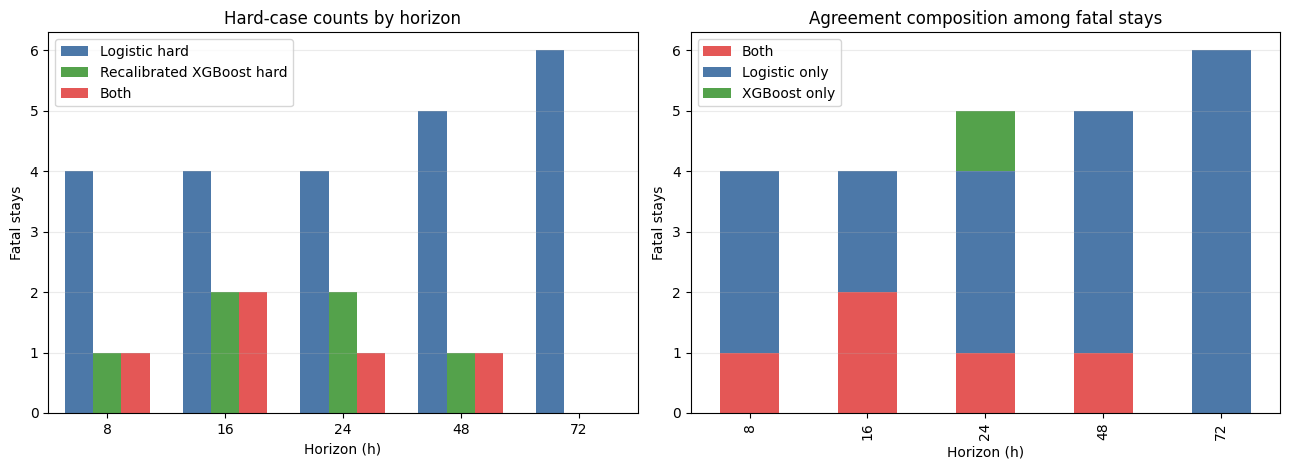

### Agreement category counts by horizon

agreement_category,horizon_h,both,logistic_only,neither,xgb_only
0,8,1,3,6,0
1,16,2,2,6,0
2,24,1,3,5,1
3,48,1,4,5,0
4,72,0,6,4,0


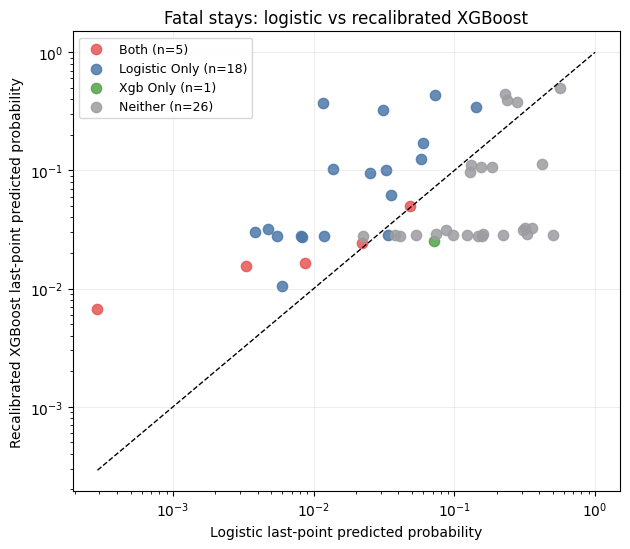

In [7]:
if not agreement_available:
    display(Markdown("_Agreement artifacts were not found at the configured default path, so this section is skipped._"))
else:
    agreement_counts = agreement_summary[
        [
            "horizon_h",
            "n_logistic_hard",
            "n_xgb_recal_hard",
            "n_both_hard",
            "n_logistic_only",
            "n_xgb_recal_only",
            "jaccard_hard_case_overlap",
            "pct_logistic_hard_confirmed_by_xgb",
            "pct_xgb_recal_hard_confirmed_by_logistic",
            "agreement_subgroup_warning",
            "warning_reason",
        ]
    ].sort_values("horizon_h").reset_index(drop=True)

    display(Markdown("### Agreement Summary Table"))
    display(agreement_counts)

    plot_frame = agreement_summary.sort_values("horizon_h").reset_index(drop=True)
    x_positions = np.arange(plot_frame.shape[0])
    bar_width = 0.24

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
    axes[0].bar(x_positions - bar_width, plot_frame["n_logistic_hard"], width=bar_width, color="#4c78a8", label="Logistic hard")
    axes[0].bar(x_positions, plot_frame["n_xgb_recal_hard"], width=bar_width, color="#54a24b", label="Recalibrated XGBoost hard")
    axes[0].bar(x_positions + bar_width, plot_frame["n_both_hard"], width=bar_width, color="#e45756", label="Both")
    axes[0].set_title("Hard-case counts by horizon")
    axes[0].set_xticks(x_positions)
    axes[0].set_xticklabels(plot_frame["horizon_h"].astype(int).astype(str))
    axes[0].set_xlabel("Horizon (h)")
    axes[0].set_ylabel("Fatal stays")
    axes[0].grid(axis="y", alpha=0.25)
    axes[0].legend()

    stacked = plot_frame.set_index("horizon_h")[["n_both_hard", "n_logistic_only", "n_xgb_recal_only"]]
    stacked.columns = ["Both", "Logistic only", "XGBoost only"]
    stacked.plot(kind="bar", stacked=True, ax=axes[1], color=["#e45756", "#4c78a8", "#54a24b"])
    axes[1].set_title("Agreement composition among fatal stays")
    axes[1].set_xlabel("Horizon (h)")
    axes[1].set_ylabel("Fatal stays")
    axes[1].grid(axis="y", alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    finalize_figure(fig)

    agreement_plot = agreement_stay.copy()
    agreement_plot["agreement_category"] = agreement_category(agreement_plot)
    category_counts = (
        agreement_plot.groupby(["horizon_h", "agreement_category"]).size().unstack(fill_value=0)
        .sort_index()
        .reset_index()
    )
    display(Markdown("### Agreement category counts by horizon"))
    display(category_counts)

    positive_values = agreement_plot[["logistic_predicted_probability", "xgb_recal_predicted_probability"]].to_numpy(dtype=float)
    positive_values = positive_values[np.isfinite(positive_values) & (positive_values > 0)]
    lower = max(float(positive_values.min()), 1e-6) if positive_values.size else 1e-6

    fig, ax = plt.subplots(figsize=(6.4, 5.6))
    for category_name, color in {
        "both": "#e45756",
        "logistic_only": "#4c78a8",
        "xgb_only": "#54a24b",
        "neither": "#9d9da1",
    }.items():
        subset = agreement_plot[agreement_plot["agreement_category"].eq(category_name)].copy()
        if subset.empty:
            continue
        ax.scatter(
            np.clip(subset["logistic_predicted_probability"].to_numpy(dtype=float), lower, None),
            np.clip(subset["xgb_recal_predicted_probability"].to_numpy(dtype=float), lower, None),
            s=55,
            alpha=0.85,
            color=color,
            label=f"{category_name.replace('_', ' ').title()} (n={len(subset)})",
        )
    ax.plot([lower, 1.0], [lower, 1.0], linestyle="--", color="black", linewidth=1.0)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Logistic last-point predicted probability")
    ax.set_ylabel("Recalibrated XGBoost last-point predicted probability")
    ax.set_title("Fatal stays: logistic vs recalibrated XGBoost")
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.legend(fontsize=9)
    plt.tight_layout()
    finalize_figure(fig)
        

## 7. Short Notebook Conclusion Cell
        

In [8]:
largest_subgroup = logistic_summary.sort_values(["n_hard_cases", "pct_fatal_hard_cases"], ascending=[False, False]).iloc[0]
smallest_subgroup = logistic_summary.sort_values(["n_hard_cases", "pct_fatal_hard_cases"], ascending=[True, True]).iloc[0]
warning_horizons = logistic_summary.loc[logistic_summary["subgroup_size_warning"].astype(bool), "horizon_h"].astype(int).tolist()

hospital_dominance_rows = []
for horizon_h, horizon_df in hospital_horizon.groupby("horizon_h", dropna=False):
    total_hard = int(horizon_df["hard_cases"].sum())
    if total_hard == 0:
        continue
    top_row = horizon_df.sort_values(["hard_cases", "fatal_stays"], ascending=[False, False]).iloc[0]
    hospital_dominance_rows.append(
        {
            "horizon_h": int(horizon_h),
            "hospital_id": str(top_row["hospital_id"]),
            "hard_cases": int(top_row["hard_cases"]),
            "share_of_hard_cases": float(top_row["hard_cases"] / total_hard),
        }
    )
hospital_dominance = pd.DataFrame(hospital_dominance_rows)

summary_lines = [
    f"- Largest hard-case subgroup: {int(largest_subgroup['horizon_h'])}h ({int(largest_subgroup['n_hard_cases'])} stays; {float(largest_subgroup['pct_fatal_hard_cases']):.1%} of fatal stays).",
    f"- Smallest hard-case subgroup: {int(smallest_subgroup['horizon_h'])}h ({int(smallest_subgroup['n_hard_cases'])} stays; {float(smallest_subgroup['pct_fatal_hard_cases']):.1%} of fatal stays).",
    f"- Subgroup-size warnings were triggered for horizons: {', '.join(str(h) for h in warning_horizons)}.",
]

if not hospital_dominance.empty:
    top_dominance = hospital_dominance.sort_values("share_of_hard_cases", ascending=False).iloc[0]
    summary_lines.append(
        f"- Largest within-horizon hospital share of hard cases: {top_dominance['hospital_id']} at {int(top_dominance['horizon_h'])}h ({int(top_dominance['hard_cases'])} cases; {float(top_dominance['share_of_hard_cases']):.1%} of that horizon's hard cases)."
    )
else:
    summary_lines.append("- No hospital-level hard-case counts were available to summarize.")

if agreement_available:
    valid_jaccard = agreement_summary["jaccard_hard_case_overlap"].dropna().astype(float)
    if not valid_jaccard.empty:
        summary_lines.append(
            f"- Cross-model agreement Jaccard ranged from {valid_jaccard.min():.2f} to {valid_jaccard.max():.2f} (median {valid_jaccard.median():.2f})."
        )
    zero_both_horizons = agreement_summary.loc[agreement_summary["n_both_hard"].eq(0), "horizon_h"].astype(int).tolist()
    if zero_both_horizons:
        summary_lines.append(
            f"- Horizons with zero agreed hard cases: {', '.join(str(h) for h in zero_both_horizons)}."
        )
    agreement_warning_horizons = agreement_summary.loc[
        agreement_summary["agreement_subgroup_warning"].astype(bool), "horizon_h"
    ].astype(int).tolist()
    summary_lines.append(
        f"- Agreement warnings were triggered for horizons: {', '.join(str(h) for h in agreement_warning_horizons)}."
    )
else:
    summary_lines.append("- Agreement artifacts were not available, so no cross-model takeaway was computed.")

display(Markdown("### First-pass takeaways\n" + "\n".join(summary_lines)))
        

### First-pass takeaways
- Largest hard-case subgroup: 72h (6 stays; 60.0% of fatal stays).
- Smallest hard-case subgroup: 8h (4 stays; 40.0% of fatal stays).
- Subgroup-size warnings were triggered for horizons: 8, 16, 24, 48, 72.
- Largest within-horizon hospital share of hard cases: asic_UK07 at 8h (3 cases; 75.0% of that horizon's hard cases).
- Cross-model agreement Jaccard ranged from 0.00 to 0.50 (median 0.20).
- Horizons with zero agreed hard cases: 72.
- Agreement warnings were triggered for horizons: 8, 16, 24, 48, 72.